In [1]:
%matplotlib ipympl
# from stage 1
import scipy.io as spio
import numpy as np
import scipy.special 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# filter
from scipy.signal import butter,filtfilt

# spike detection
from scipy.signal import find_peaks

# PCA
from sklearn.decomposition import PCA

# normalise
from sklearn.preprocessing import MinMaxScaler

# classifier
# import all packages needed to run the code
from sklearn import metrics
import scipy.interpolate as interp
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import BatchNormalization 
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# save
from scipy.io import savemat

# Preprocessing Data Functions

In [2]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], analog=False, btype='band')
        y = filtfilt(b, a, data)
        return y

In [3]:
# function to normalise data
def NormaliseData(inData):
    """ Normalise array

    Normalise input and target data

    :param: inData - numpy array of input data

    :return: inData - numpy array of normalised input data
    """

    inData = inData.astype("float32") / 255

    max_val = max(inData)
    min_val = min(inData)
    range_val = max_val - min_val 

    normData = inData.copy()
    j = 0
    for i in inData:
        normData[j] = (i - min_val)/range_val 

    return normData

# Load Data

D1: This is a low noise recording that is fully labelled, it has both Index and Class vectors that are
correct. You should use this for training your classifier. <br>
D2: This is a low noise recording that does not contain labels (i.e., it only contains the d vector). <br>
D3: This is a high noise recording that does not contain labels (i.e., it only contains the d vector). <br>
D4: This is a high noise recording that does not contain labels (i.e., it only contains the d vector). <br>

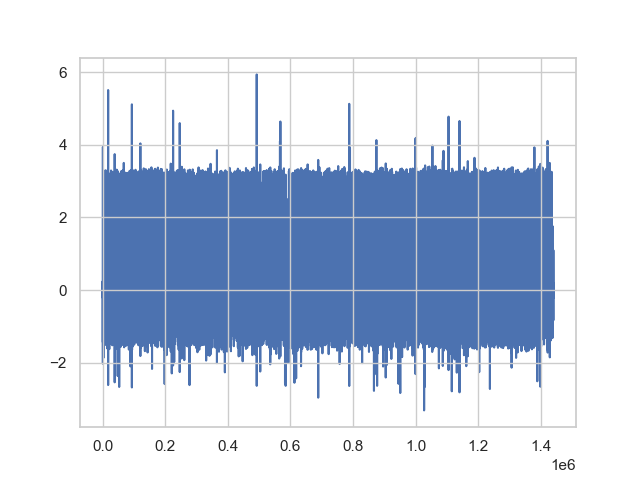

In [4]:
mat = spio.loadmat('D1.mat', squeeze_me=True)
d1 = mat['d'] # Raw time domain recording (1440000 samples), 25 kHz sampling frequency.
Index1 = mat['Index'] # The location in the recording (in samples) of the start of each spike.
Class1 = mat['Class'] # The class (1, 2, 3, 4 or 5), i.e the type of neuron that generated each spike.

plt.figure(0)
plt.plot(d1)

# Filter - better for peak detection (from sub3).
fs = 25000      # sample rate, Hz
order = 1       # sin wave can be approx represented as quadratic
lowcut = 300 # 300, 250
highcut  = 2500 #3000, 4050

# Filter
d1_f = butter_bandpass_filter(d1, lowcut, highcut, fs, order)

plt.figure(0)
plt.cla()
plt.clf()
plt.plot(d1_f, zorder=-1)

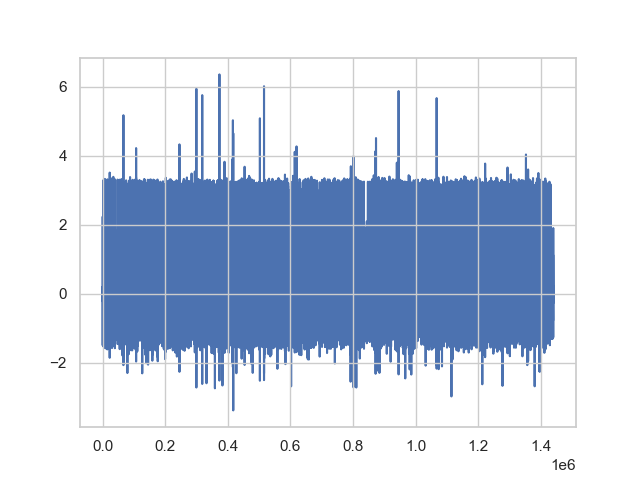

In [5]:
# Load dataset D2 into Python
mat = spio.loadmat('D2.mat', squeeze_me=True)
d2 = mat['d']

plt.figure(1)
plt.plot(d2)

# Filter
d2_f = butter_bandpass_filter(d2, lowcut, highcut, fs, order)

plt.figure(1)
plt.cla()
plt.clf()
plt.plot(d2_f, zorder=-1)

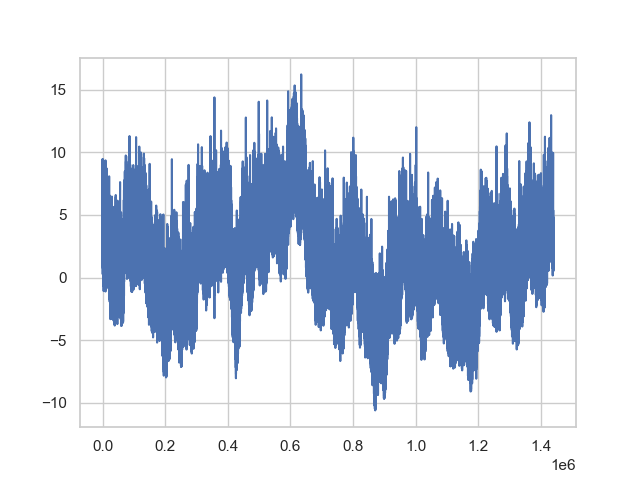

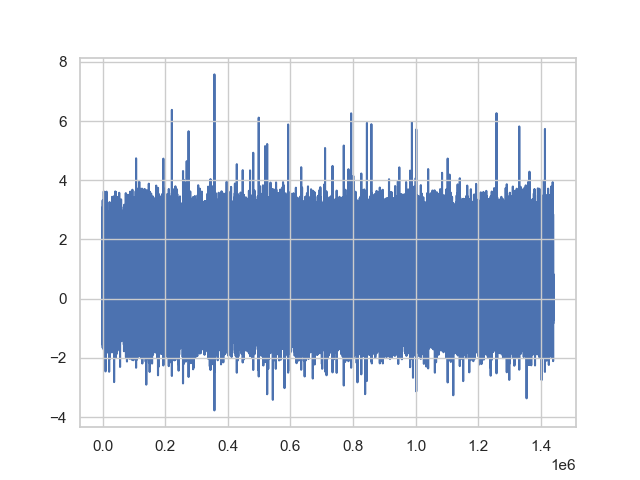

In [6]:
# Load dataset D3 into Python
mat = spio.loadmat('D3.mat', squeeze_me=True)
d3 = mat['d']

plt.figure(2)
plt.plot(d3)

# Filter
d3_f = butter_bandpass_filter(d3, lowcut, highcut, fs, order)

plt.figure(3)
plt.plot(d3_f, zorder=-1)

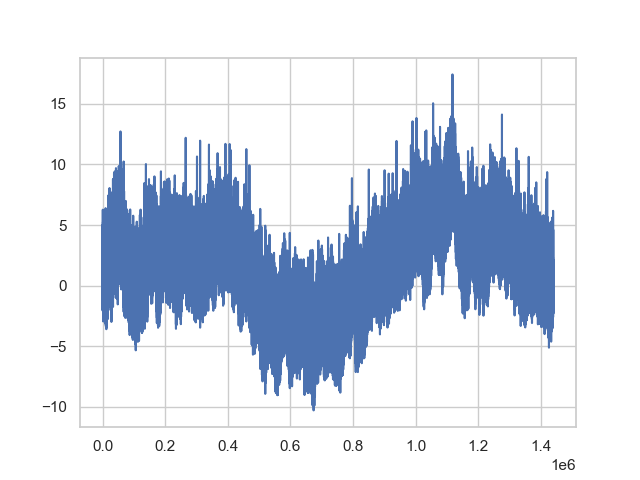

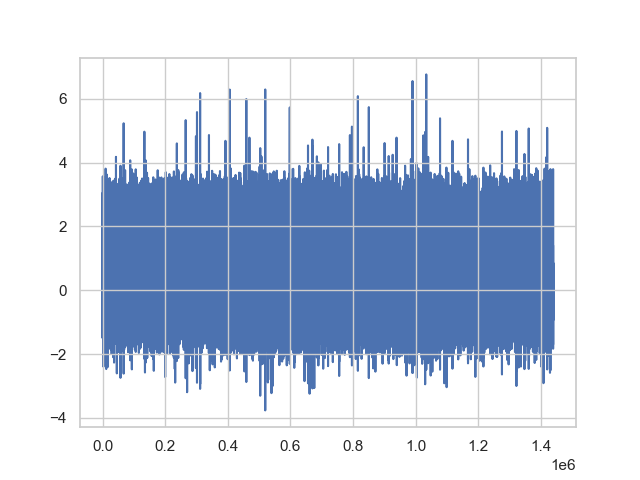

In [7]:
# Load dataset D2 into Python
mat = spio.loadmat('D4.mat', squeeze_me=True)
d4 = mat['d']

plt.figure(4)
plt.plot(d4)

d4_f = butter_bandpass_filter(d4, lowcut, highcut, fs, order)

plt.figure(5)
plt.plot(d4_f, zorder=-1)

# Spike Detection

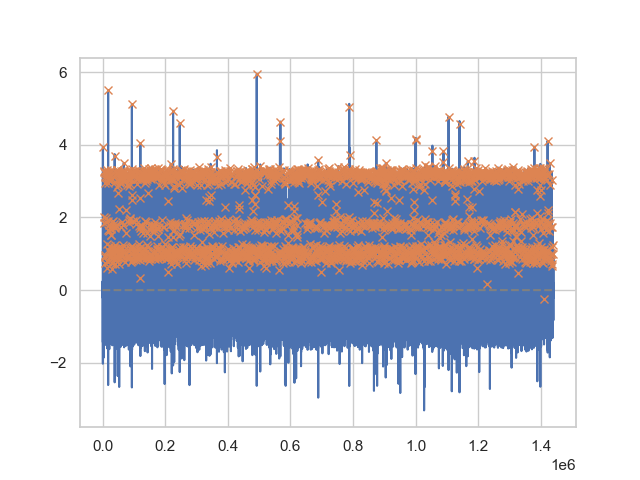

In [8]:
# calculate standard deviation of signal using Donoho's estimation
# std = (np.median(abs(d1 - np.mean(d1))/0.6745))
std = (np.median(abs(d1)/0.6745))

# spike detection threshold
ts = std*3 # some papers use 5*std

peaks1, _ = find_peaks(d1, prominence=1.6, height = ts)
# peaks1, _ = find_peaks(d1, height = ts)

plt.figure(6)
plt.plot(d1_f)
plt.plot(peaks1, d1_f[peaks1], "x")
plt.plot(np.zeros_like(d1), "--", color="gray")
plt.show()

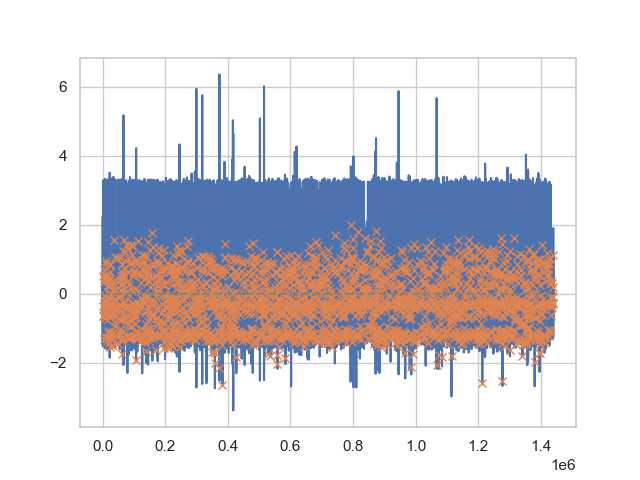

In [9]:
# calculate standard deviation of signal using Donoho's estimation
# std2 = (np.median(abs(d2 - np.mean(d2))/0.6745))
std2 = (np.median(abs(d2)/0.6745))

# spike detection threshold
ts2 = std2*3 # some papers use 5*std

peaks2, _ = find_peaks(d2, prominence=1.6, height=ts2)
# peaks2, _ = find_peaks(d2, height=ts2)

Index2 = peaks2.copy()
for i in range(len(Index2)):
    Index2[i] = Index2[i] - 10

plt.figure(7)
plt.plot(d2_f)
plt.plot(Index2, d2_f[Index2], "x")
plt.plot(np.zeros_like(d2), "--", color="gray")
plt.show()    

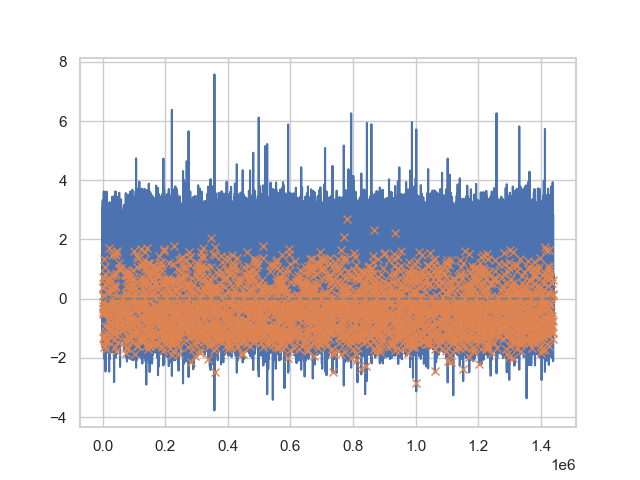

In [10]:
# calculate standard deviation of signal using Donoho's estimation
# std3 = (np.median(abs(d3_f - np.mean(d3_f))/0.6745))
std3 = (np.median(abs(d3_f)/0.6745))
# spike detection threshold
ts3 = std3*3 # some papers use 5*std

peaks3, _ = find_peaks(d3_f, prominence=1.6, height=ts3)
# peaks3, _ = find_peaks(d3_f, height=ts3)

Index3 = peaks3.copy()
for i in range(len(Index3)):
    Index3[i] = Index3[i] - 10

plt.figure(8)
plt.plot(d3_f)
plt.plot(Index3, d3_f[Index3], "x")
plt.plot(np.zeros_like(d3_f), "--", color="gray")
plt.show()  

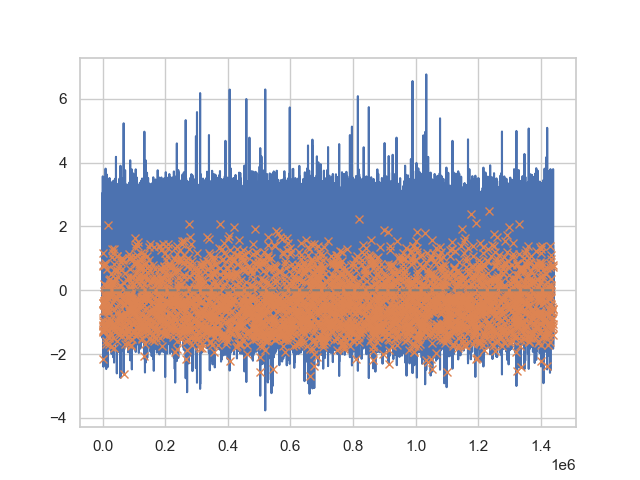

In [11]:
# calculate standard deviation of signal using Donoho's estimation
# std4 = (np.median(abs(d4_f - np.mean(d4_f))/0.6745))
std4 = (np.median(abs(d4_f)/0.6745))

# spike detection threshold
ts4 = std4*3 # some papers use 5*std

peaks4, _ = find_peaks(d4_f, prominence=1.6, height=ts4)
# peaks4, _ = find_peaks(d4_f, height=ts4)

Index4 = peaks4.copy()
for i in range(len(Index4)):
    Index4[i] = Index4[i] - 10

plt.figure(9)
plt.plot(d4_f)
plt.plot(Index4, d4_f[Index4], "x")
plt.plot(np.zeros_like(d4_f), "--", color="gray")
plt.show() 

In [12]:
# Sort index and class
Index1_sorted, Class1_sorted = zip(*sorted(zip(Index1, Class1)))
Index2_sorted = sorted(Index2)
Index3_sorted = sorted(Index3)
Index4_sorted = sorted(Index4)

# Define period of each spike
n_2ms = int((25e3) * 2.5e-3) # int((25e3)/downsample_factor * 2e-3) # 50 for 25kHz 
if n_2ms%2 != 0:
    n_2ms = n_2ms - 1
n = int((25e3) * 0.5e-3) #int(n_2ms/2)
if n%2 != 0:
    n = n - 1
# spike = np.zeros([n_2ms,len(Index1)])
# spike2 = np.zeros([n_2ms,len(Index2)])
# spike3 = np.zeros([n_2ms,len(Index3)])
# spike4 = np.zeros([n_2ms,len(Index4)])


# scaler = MinMaxScaler()
# # transform data
# d1_n = scaler.fit_transform(d1_f)
# d2_n = scaler.fit_transform(d2_f)
# d3_n = scaler.fit_transform(d3_f)
# d4_n = scaler.fit_transform(d4_f)

d1_n = NormaliseData(d1_f)
d2_n = NormaliseData(d2_f)
d3_n = NormaliseData(d3_f)
d4_n = NormaliseData(d4_f)

spike = np.zeros([n_2ms+n,len(Index1)])
spike2 = np.zeros([n_2ms+n,len(Index2)])
spike3 = np.zeros([n_2ms+n,len(Index3)])
spike4 = np.zeros([n_2ms+n,len(Index4)])

# Set up arrays for neural network d1
k = 0
for i in range(n,len(d1)-n_2ms):
    if k < len(Index1_sorted) and i == Index1_sorted[k]:
        spike[:,k] = d1_n[i-n:i+n_2ms]
        # spike[:,k] = d1_n[i:i+n_2ms]
        k = k + 1

# Set up arrays for neural network d2
k = 0
for i in range(n,len(d2)-n_2ms):
    if k < len(Index2_sorted) and i == Index2_sorted[k]:
        spike2[:,k] = d2_n[i-n:i+n_2ms]
        # spike2[:,k] = d2_n[i:i+n_2ms]
        k = k + 1 

# Set up arrays for neural network d3
k = 0
for i in range(n,len(d3_f)-n_2ms):
    if k < len(Index3_sorted) and i == Index3_sorted[k]:
        spike3[:,k] = d3_n[i-n:i+n_2ms]
        # spike3[:,k] = d3_n[i:i+n_2ms]
        k = k + 1 

# Set up arrays for neural network d4
k = 0
for i in range(n,len(d4_f)-n_2ms):
    if k < len(Index4_sorted) and i == Index4_sorted[k]:
        spike4[:,k] = d4_n[i-n:i+n_2ms]
        # spike4[:,k] = d4_n[i:i+n_2ms]
        k = k + 1 

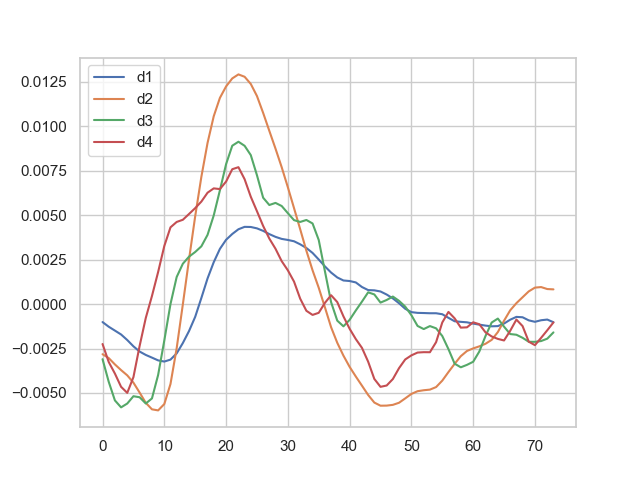

In [13]:
plt.figure(10)
plt.cla()
plt.clf()
plt.plot(spike[:,11])
plt.plot(spike2[:,2])
plt.plot(spike3[:,2])
plt.plot(spike4[:,2])
plt.legend(['d1', 'd2', 'd3', 'd4'], loc='upper left') #, 'd3', 'd4'
plt.show() 

# Dimension Reduction

In [14]:
# training
x = len(spike[0])
d1_spikes_train = spike[:,0:int(x*0.9)].transpose()
d1_spikes_test = spike[:,int(x*0.9):].transpose()
d2_spikes_test = spike2.transpose()
d3_spikes_test = spike3.transpose()
d4_spikes_test = spike4.transpose()
class1_train = Class1_sorted[0:int(x*0.9)]
class1_test = Class1_sorted[int(x*0.9):]

print(d1_spikes_train.shape)
print(d1_spikes_test.shape)
print(d2_spikes_test.shape)
print(d3_spikes_test.shape)
print(d4_spikes_test.shape)

(2477, 74)
(276, 74)
(2322, 74)
(3381, 74)
(3626, 74)


Total Variance Explained:  0.8691689118177924


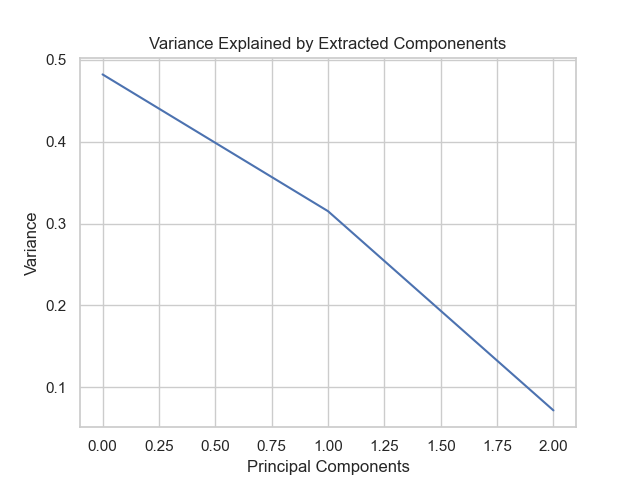

In [15]:
# Select number of components to extract
pca_num = 3
pca = PCA(n_components = pca_num)
# Fit to the training data
pca.fit(d1_spikes_train)

# Determine amount of variance explained by components
print("Total Variance Explained: ", np.sum(pca.explained_variance_ratio_))

# Plot the explained variance
plt.figure(11)
plt.cla()
plt.clf()
plt.plot(pca.explained_variance_ratio_)
plt.title('Variance Explained by Extracted Componenents')
plt.ylabel('Variance')
plt.xlabel('Principal Components')
plt.show()

# Classifier

In [16]:
# Extract the principal components from the training data
train_ext = pca.fit_transform(d1_spikes_train)
# Transform the test data using the same components
test_ext = pca.transform(d1_spikes_test)
test_ext2 = pca.transform(d2_spikes_test)
test_ext3 = pca.transform(d3_spikes_test)
test_ext4 = pca.transform(d4_spikes_test)

Feature shape: (3,)
Epoch 1/500
31/31 [==============================] - 1s 7ms/step - loss: 1.9871 - accuracy: 0.5563 - val_loss: 1.9750 - val_accuracy: 0.9214
Epoch 2/500
31/31 [==============================] - 0s 2ms/step - loss: 1.9657 - accuracy: 0.4917 - val_loss: 1.9551 - val_accuracy: 0.3730
Epoch 3/500
31/31 [==============================] - 0s 2ms/step - loss: 1.9466 - accuracy: 0.2625 - val_loss: 1.9362 - val_accuracy: 0.2298
Epoch 4/500
31/31 [==============================] - 0s 2ms/step - loss: 1.9283 - accuracy: 0.2267 - val_loss: 1.9173 - val_accuracy: 0.2238
Epoch 5/500
31/31 [==============================] - 0s 2ms/step - loss: 1.9100 - accuracy: 0.2251 - val_loss: 1.8984 - val_accuracy: 0.2177
Epoch 6/500
31/31 [==============================] - 0s 2ms/step - loss: 1.8914 - accuracy: 0.2135 - val_loss: 1.8792 - val_accuracy: 0.2157
Epoch 7/500
31/31 [==============================] - 0s 2ms/step - loss: 1.8724 - accuracy: 0.2150 - val_loss: 1.8604 - val_accuracy: 

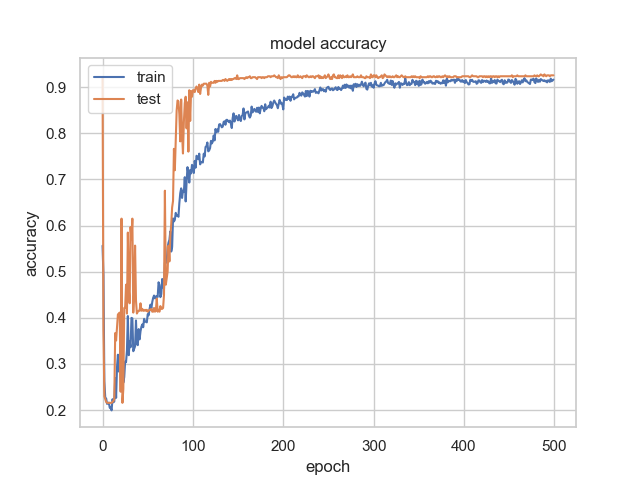

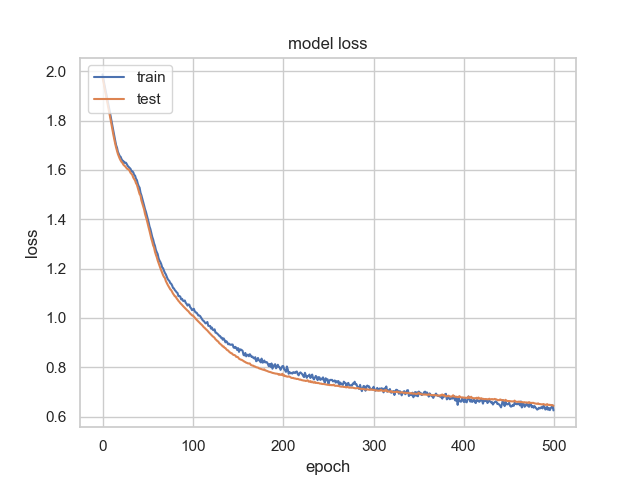

In [17]:
# Configuration options 
feature_vector_length = pca_num
num_classes = 6

# Reshape the data 
X_train = train_ext 
X_test = test_ext 

# Convert target classes to categorical ones
Y_train = to_categorical(class1_train, num_classes)
Y_test = to_categorical(class1_test, num_classes)

# Set the input shape
input_shape = (feature_vector_length,)
print(f'Feature shape: {input_shape}')

# Create the model
model = Sequential()
model.add(Dense(32, input_shape=input_shape, activation='relu', kernel_regularizer='l1')) #32, 50 for 0.8 test train split
model.add(Dense(16, activation='relu')) #12
# model.add(BatchNormalization()) #12
# model.add(Dense(8, activation='relu')) #12
model.add(Dropout(0.1)) # 0.1 0.3 for 0.8 test train split
model.add(Dense(num_classes, activation='softmax')) #softmax=good, sigmoid=good, tanh=bad 

# Configure the model and start training
optimizer = Adam(learning_rate=0.0005)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
# model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

es_callback = EarlyStopping(monitor='val_loss', patience=5)
history = model.fit(X_train, Y_train, epochs=500, batch_size=64, verbose=1, validation_split=0.2, callbacks=[es_callback]) 

# Test the model after training
test_results = model.evaluate(X_test, Y_test, verbose=1)
print(f'Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]}%')

# summarize history for accuracy
plt.figure(12)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.figure(13)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

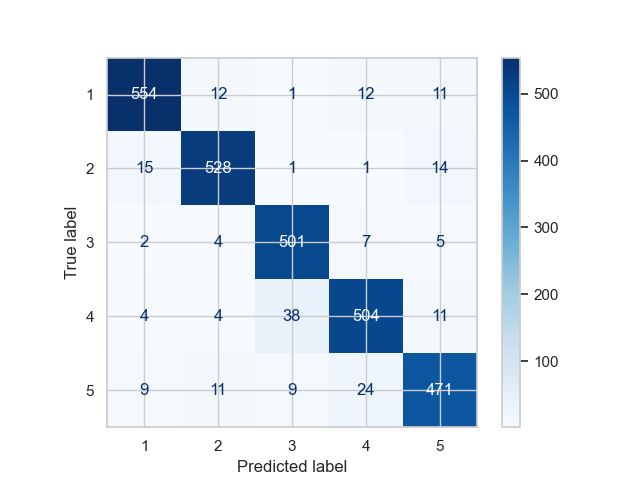

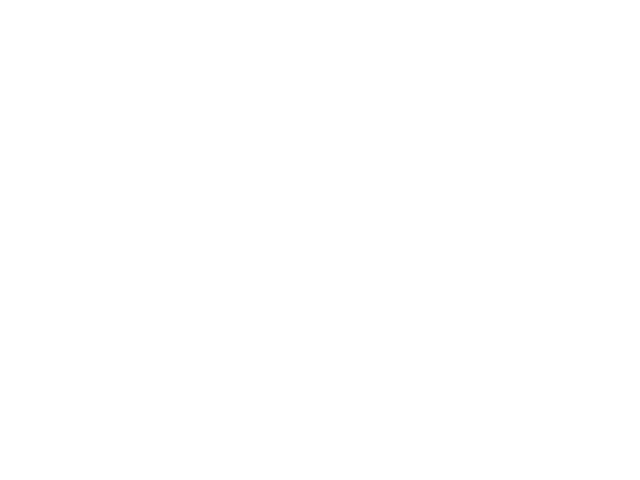

In [18]:
class1_in = pca.fit_transform(spike.transpose())

class1_out = model.predict(class1_in)
Class1_pred = np.zeros(len(class1_out), dtype=np.int64)
i = 0
for l in class1_out:
    Class1_pred[i] = l.argmax()
    i = i+1

# print(classification_report(Class1_sorted, Class1_pred, labels=[1, 2, 3, 4, 5], target_names=[1, 2, 3, 4, 5]))    
cm = confusion_matrix(Class1_sorted, Class1_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3, 4, 5])
plt.figure(14)
disp = disp.plot(cmap=plt.cm.Blues,values_format='g')
plt.show()

In [19]:
# # Test the model after training
class2_out = model.predict(test_ext2)
Class2 = np.zeros(len(class2_out), dtype=np.int64)
i = 0
n1 = 0
n2 = 0
n3 = 0
n4 = 0
n5 = 0
for l in class2_out:
    Class2[i] = l.argmax()
    
    if Class2[i] == 1:
        n1 = n1 + 1
    elif Class2[i] == 2:
        n2 = n2 + 1   
    elif Class2[i] == 3:
        n3 = n3 + 1
    elif Class2[i] == 4:
        n4 = n4 + 1    
    else:
        n5 = n5 + 1        

    i = i + 1

print("Number of 1s predicted: ", n1)    
print("Number of 2s predicted: ", n2)    
print("Number of 3s predicted: ", n3)    
print("Number of 4s predicted: ", n4)    
print("Number of 5s predicted: ", n5)    


Number of 1s predicted:  501
Number of 2s predicted:  473
Number of 3s predicted:  447
Number of 4s predicted:  453
Number of 5s predicted:  448


In [20]:
# col = ['k', 'r', 'b', 'c', 'g']

# plt.figure(15)
# plt.cla()
# plt.clf()
# for i in range(len(spike[1,:])):
#     plt.plot(spike[:,i], c=col[Class1_sorted[i]-1])
# plt.show() 

In [21]:
# Plot the explained variance
# plt.figure(16)
# plt.cla()
# plt.clf()
# for i in range(len(train_ext[:,1])):
#     plt.scatter(train_ext[i,0], train_ext[i,1], c=col[Class1_sorted[i]-1])
# plt.show()

In [22]:
# plt.figure(17)
# plt.cla()
# plt.clf()
# for i in range(len(spike2[1,:])):
#     plt.plot(spike2[:,i], c=col[Class2[i]-1])
# plt.show() 

In [23]:
# Plot the explained variance
# plt.figure(18)
# plt.cla()
# plt.clf()
# for i in range(len(test_ext2[:,1])):
#     plt.scatter(test_ext2[i,0], test_ext2[i,1], c=col[Class2[i]-1])
# plt.show()

In [24]:
# mdic = {"d": d2, "Index": Index2_sorted, "Class": Class2 }
# savemat("D2_submit.mat", mdic)

In [25]:
# class3_out = model.predict(d3_spikes_test)
class3_out = model.predict(test_ext3)
Class3 = np.zeros(len(class3_out), dtype=np.int64)
i = 0
n1 = 0
n2 = 0
n3 = 0
n4 = 0
n5 = 0
for l in class3_out:
    Class3[i] = int(l.argmax())

    if Class3[i] == 1:
        n1 = n1 + 1
    elif Class3[i] == 2:
        n2 = n2 + 1   
    elif Class3[i] == 3:
        n3 = n3 + 1
    elif Class3[i] == 4:
        n4 = n4 + 1    
    else:
        n5 = n5 + 1     

    i = i + 1

print("Number of 1s predicted: ", n1)    
print("Number of 2s predicted: ", n2)    
print("Number of 3s predicted: ", n3)    
print("Number of 4s predicted: ", n4)    
print("Number of 5s predicted: ", n5)       

Number of 1s predicted:  714
Number of 2s predicted:  686
Number of 3s predicted:  598
Number of 4s predicted:  741
Number of 5s predicted:  642


In [26]:
# plt.figure(19)
# plt.cla()
# plt.clf()
# for i in range(len(spike3[1,:])):
#     plt.plot(spike3[:,i], c=col[Class3[i]-1])
# plt.show() 

In [27]:
# Plot the explained variance
# plt.figure(20)
# plt.cla()
# plt.clf()
# for i in range(len(test_ext3[:,1])):
#     plt.scatter(test_ext3[i,0], test_ext3[i,1], c=col[Class3[i]-1])
# plt.show()

In [28]:
# mdic = {"d": d3, "Ix": Index3_sorted, "Class": Class3 }
# savemat("D3_submit.mat", ndemdic)

In [29]:
# class4_out = model.predict(d4_spikes_test)
class4_out = model.predict(test_ext4)
Class4 = np.zeros(len(class4_out), dtype=np.int64)
i = 0
n1 = 0
n2 = 0
n3 = 0
n4 = 0
n5 = 0
for l in class4_out:
    Class4[i] = l.argmax()

    if Class4[i] == 1:
        n1 = n1 + 1
    elif Class4[i] == 2:
        n2 = n2 + 1   
    elif Class4[i] == 3:
        n3 = n3 + 1
    elif Class4[i] == 4:
        n4 = n4 + 1    
    else:
        n5 = n5 + 1       
    i = i + 1

print("Number of 1s predicted: ", n1)    
print("Number of 2s predicted: ", n2)    
print("Number of 3s predicted: ", n3)    
print("Number of 4s predicted: ", n4)    
print("Number of 5s predicted: ", n5)       

Number of 1s predicted:  768
Number of 2s predicted:  726
Number of 3s predicted:  604
Number of 4s predicted:  799
Number of 5s predicted:  729


In [30]:
# plt.figure(21)
# plt.cla()
# plt.clf()
# for i in range(len(spike4[1,:])):
#     plt.plot(spike4[:,i], c=col[Class4[i]-1])
# plt.show() 

In [31]:
# Plot the explained variance
# plt.figure(22)
# plt.cla()
# plt.clf()
# for i in range(len(test_ext4[:,1])):
#     plt.scatter(test_ext4[i,0], test_ext4[i,1], c=col[Class4[i]-1])
# plt.show()

In [32]:
# mdic = {"d": d4, "Index": Index4_sorted, "Class": Class4 }
# savemat("D4_submit.mat", mdic)